# Particle Swarm Optimisation with Dynamic Strategy

In [141]:
import numpy as np
import matplotlib.pyplot as plt

## Sperimental setup

In [142]:

facilities = {
    'ES': [(3, 37), (42, 96), (45, 60), (50, 25), (83, 72),(98, 38)],
    'HS': [(40, 20), (51, 60), (95, 51)],
    'CS': [(10, 55), (15, 15), (15, 78), (15, 88), (20, 23),(20, 70), (32, 42), (35, 60), (40, 76), (52, 78),(52, 96), (55, 33), (75, 27)],
    'RS': [(17.5, 82.5), (55.5, 82.5), (94.5, 6.5)]
}

infrastructure = {
    'Roads': [
    # Major Horizontals
    [(0, 7), (100, 7)],
    [(0, 5.5), (100, 5.5)],
    [(0, 58), (100, 58)],
    [(0, 56.5), (100, 56.5)],
    [(0, 94), (100, 94)],
    [(0, 92.5), (100, 92.5)],
    
    [(19.6, 74), (100, 74)],

    # Minor Horizontals (interrupted by the center block)
    [(0, 40), (34, 40)],
    [(42, 31), (76, 31)],
    
    # Major Verticals
    [(17, 0), (17, 100)],
    [(18.5, 0), (18.5, 100)],
    [(77, 7), (77, 58)],
    
    # Minor Verticals (interrupted by the center block)
    [(42, 7), (42, 31)],
    [(34, 40), (34, 58)],
    [(55.5, 58), (55.5, 82.5)],
    
    # Diagonals branching off the center block
    [(40, 58), (30, 74)],
    [(34, 40), (42, 31)], # Up-right diagonal
    ],
    
    'Railways': [
        [(0, 82.5), (100,82.5)],
        [(0, 82.5), (17.5, 82.5), (55.5, 82), (83, 68), (94.5, 35), (94.35,6.5), (94.5, 0)] 
    ]
}

map_styles = {
    'ES': {'color': '#ff4c4c', 'marker': 'o', 'size': 80},
    'HS':       {'color': '#4c72ff', 'marker': 'o', 'size': 80},
    'CS':           {'color': "#00ff00", 'marker': 'o', 'size': 80},
    'RS':           {'color': '#ffcc00', 'marker': 'o', 'size': 80},
    'Roads':                   {'color': "#B6B5B5", 'linestyle': '-', 'linewidth': 7, 'alpha': 1},
    'Railways':                {'color': '#000000', 'linestyle': '--', 'linewidth': 2, 'alpha': 0.8, 'smooth': True}
}

In [143]:
def smooth_path(path, iterations=4):
    """
    Smooths a path using Chaikin's corner-cutting algorithm.
    This strictly prevents 'wobbling' or overshooting.
    """
    if len(path) < 3:
        return path

    current_path = path
    # The more iterations, the smoother the curve. 4 or 5 is usually perfect.
    for _ in range(iterations):
        new_path = [current_path[0]] # Anchor the very first starting point
        
        for i in range(len(current_path) - 1):
            p0 = current_path[i]
            p1 = current_path[i+1]
            
            # Find the points 25% and 75% of the way along the line segment
            q = (0.75 * p0[0] + 0.25 * p1[0], 0.75 * p0[1] + 0.25 * p1[1])
            r = (0.25 * p0[0] + 0.75 * p1[0], 0.25 * p0[1] + 0.75 * p1[1])
            
            # Add those new points to shave off the corner
            new_path.extend([q, r])
            
        new_path.append(current_path[-1]) # Anchor the very last ending point
        current_path = new_path
        
    return current_path

def plot_city_map(point_data, line_data, styles):
    """
    Plots a generic 2D map. Now supports automatic smoothing for lines.
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # 1. Plot Lines (Roads, Railways)
    for category, paths in line_data.items():
        style = styles.get(category, {})
        color = style.get('color', 'black')
        linestyle = style.get('linestyle', '-')
        linewidth = style.get('linewidth', 2)
        alpha = style.get('alpha', 1.0)
        
        # Check if the style dictionary requests smoothing for this category
        smooth = style.get('smooth', False) 
        
        for i, path in enumerate(paths):
            if not path: 
                continue
            
            # Apply smoothing if requested
            plot_path = smooth_path(path) if smooth else path
            
            x_coords, y_coords = zip(*plot_path)
            label = category if i == 0 else ""
            
            ax.plot(x_coords, y_coords, color=color, linestyle=linestyle, 
                    linewidth=linewidth, alpha=alpha, label=label, zorder=1)

    # 2. Plot Points (Facilities)
    for category, points in point_data.items():
        if not points: 
            continue
            
        style = styles.get(category, {})
        color = style.get('color', 'black')
        marker = style.get('marker', 'o')
        size = style.get('size', 70)
        
        x_coords, y_coords = zip(*points)
        ax.scatter(x_coords, y_coords, color=color, marker=marker, s=size, 
                   edgecolors='black', linewidths=1.5, label=category, zorder=3)

    # 3. Environment & Styling
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    if line_data:
        ax.grid(False)
    else:
        ax.grid(True, linestyle=':', alpha=0.8, zorder=0)

    ax.set_aspect('equal')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title('Procedural City Infrastructure Map')
    
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

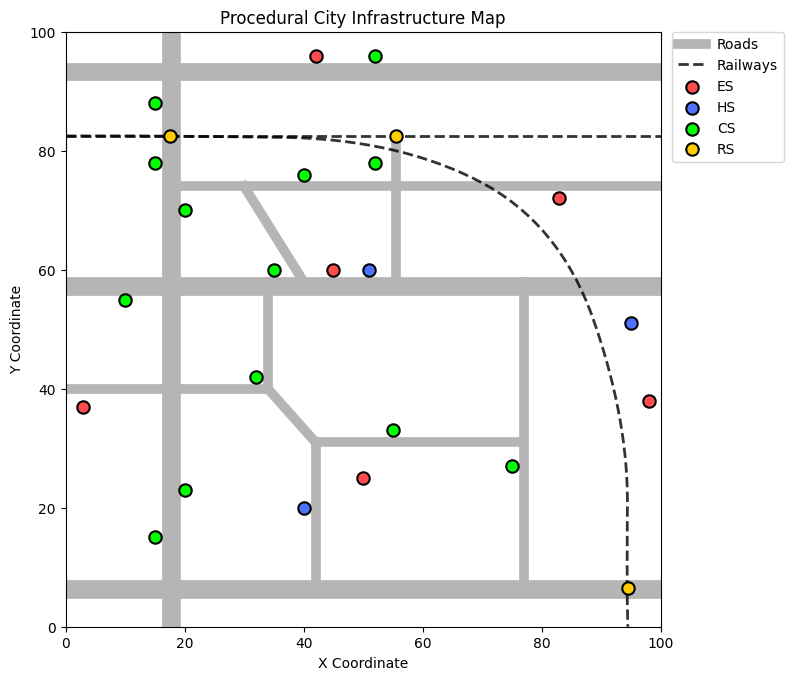

In [144]:
plot_city_map(facilities,infrastructure, map_styles)
# plot_city_map_smooth(facilities,{}, map_styles)